In [1]:
import h5py
import numpy as np
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt
import pylab as pyl
import pywt
import pandas as pd

import os
import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

pytorch_fid_src = project_root / "lib" / "pytorch-fid-master" / "src"
if str(pytorch_fid_src) not in sys.path:
    sys.path.insert(0, str(pytorch_fid_src))

from lib.cea_lib.signal1D import*
from lib.cea_lib.general import*
from lib.cea_lib.output import*
from lib.cea_lib.data_loader import*

In [2]:
data, labels = load_RTCEA("../data/RTCEA_bimode.hdf5")
atwood = create_atwood_dic(labels)

idxs = atwood[0.3]
sim = data[idxs,:,:] 
time = labels[idxs,1]

<!-- \newcommand{\ip}[2]{\langle #1, #2 \rangle} -->

# Comparison of 1D approaches

### Wavelets

The wavelet basis is written as
$$\quad B = \{ \psi_{j,n}\ ,\ (j,n)\in\mathbb{Z}^2 \ \ |\ \ \psi_{j,n} = \frac{1}{2^j}\psi^k( \frac{x-2^j n}{2^j} ) \}$$

**Linear wavelets**
$$f_J(x)=\sum_{ j \le J }\sum_{ j \le n } \langle f,\psi_{j,n}\rangle \psi_{j,n} \ ,\quad J=log_2(n)-1$$

**Nonlinear wavelets**
$$f_M(x)=\sum_{ (j,n) \in \Lambda_M } \langle f,\psi_{j,n} \rangle \psi_{j,n} \ , \quad \Lambda_M=\{c_{j,n}\ge M \ \ |\ \ c_{j,n}=\langle f,\phi_{j,n}\rangle\}$$

### Fourier

The Fourier basis is written as
$$\quad F = \{ \phi_{k}\ ,\ k\in\mathbb{Z} \ \ |\ \ \phi_{k} = e^{2\pi ikx} \}$$

**Linear Fourier transform (low frequencies)**
$$f_K(x)=\sum_{ |k| \le K }\langle f, \phi_k \rangle \phi_k$$

**Nonlinear Fourier transform (dominant frequencies)**
$$f_H(x)=\sum_{ k \in \Lambda_H } \langle f,\phi_m \rangle \phi_m \ , \quad \Lambda_H=\{c_k\ge H \ \ |\ \ c_k=\langle f, \phi_k \rangle \}$$

### PCA
$$X = U\Sigma V^T$$
with $Cv_i = \lambda_i$, so $V$ is the matrix of eigenvectors of $C$ and $\Sigma$ is the matrix containing the square roots of the eigenvalues ($\Sigma = \mathrm{diag}(\sqrt{\lambda_1}, \sqrt{\lambda_2}, ...)$). Finally, $U=X_c V \Sigma^{-1}$ is the projection of the data onto the new basis.
Thus $$f_a = V^T(f-\mu)$$

### Choice of the error used to compare signal compression

Naive choice: L2 norm


In [3]:
signals = sim[:,:,sim.shape[2]//2]
x = sim.shape[2]//2

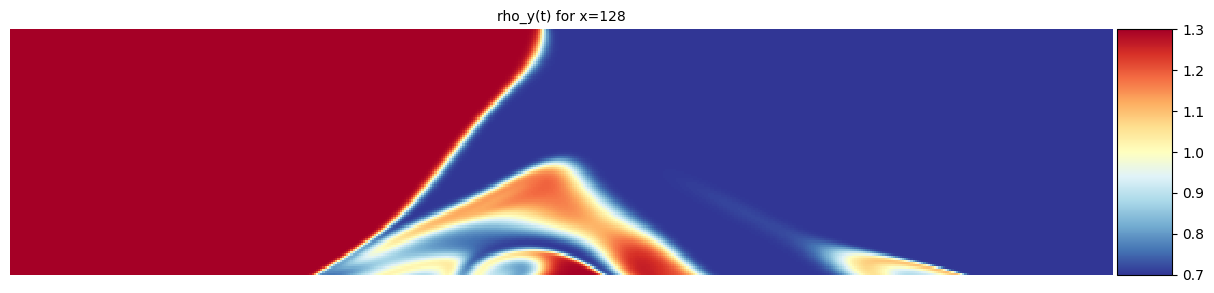

In [4]:
plt.figure(figsize=(15,15))
imageplot(signals, "rho_y(t) for x=128",sbpt=[1,1,1], cmap='RdYlBu_r', colorbar=True)

## Computations
### Parameters

In [18]:
T = 0.05
iteration = 50 #int(np.log2(n[0]))
wavelet = "sym6"
alpha = 0.2
t = signals.shape[0]-1 

pACP = 90 #%
methods = [
    "Linear wavelets",
    "Nonlinear wavelets",
    "Linear Fourier",
    "Nonlinear Fourier",
    "PCA",
    "PCA " + str(pACP) + "%"
]

n = np.full(len(methods), int(signals[0,:].shape[0] /2)) # n value for each method 
errors = np.zeros((len(methods), iteration, 2))

si = np.zeros((len(methods), signals.shape[1]))

### Parametric PCA bases
Construction of two PCA bases to assess the generalization ability of PCA for this problem.
- 100% basis: built from the complete simulation time series, such that $X = U\Sigma V^T | X=\{x_{l}(t) | t \in [0;t_{max}] \}$
- 95% basis: built from 95% of the simulation time series, such that $X_{95} = U_{95}\Sigma_{95} V^T_{95} | X=\{x_{l}(t) | t \in [0;0.95\cdot t_{max}] \}$


In [19]:
base_acp = doACP(signals)
# s = int(0.95*signals.shape[0])
# sbase_acp = doACP(signals[:s])      # PCA is computed on the first 95% of the simulation to assess generalization

rng = np.random.default_rng(seed=42)  # seed for reproducibility
s_idx = rng.choice(signals.shape[0], size=int((pACP/100)*signals.shape[0]), replace=False)
sbase_acp = doACP(signals[s_idx])

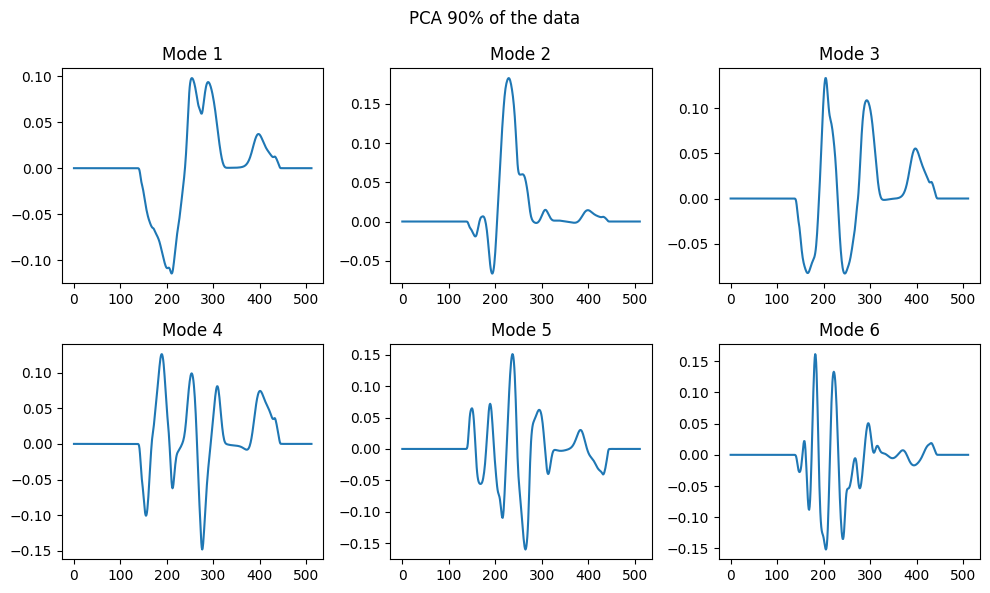

In [20]:
plot_acp_modes(sbase_acp, "PCA "+str(pACP)+"% of the data")

### Eigenvector optimization loop


In [21]:
for i in range(iteration):
    si[0,:] = wavelet_lineaire(signals[t],n[0],wavelet)
    si[1,:] = wavelet_non_lineaire(signals[t],n[1],wavelet)
    si[2,:] = fourier_lineaire(signals[t],n[2])
    si[3,:] = fourier_non_lineaire(signals[t],n[3])
    si[4,:] = acp_non_lineaire(base_acp, signals[t],n[4])
    si[5,:] = acp_non_lineaire(sbase_acp, signals[t],n[5])

    for j in range(len(methods)):
        err = np.linalg.norm(si[j] - signals[t])
        errors[j, i, 0] = n[j]
        errors[j, i, 1] = err
        
        if err < T:
            n[j] *= (1 - alpha)
        else:
            n[j] *= (1 + alpha)
            n[j] = max(1, min(len(signals[t]), int(n[j])))

print(n)

[289  76 409 409  26  26]


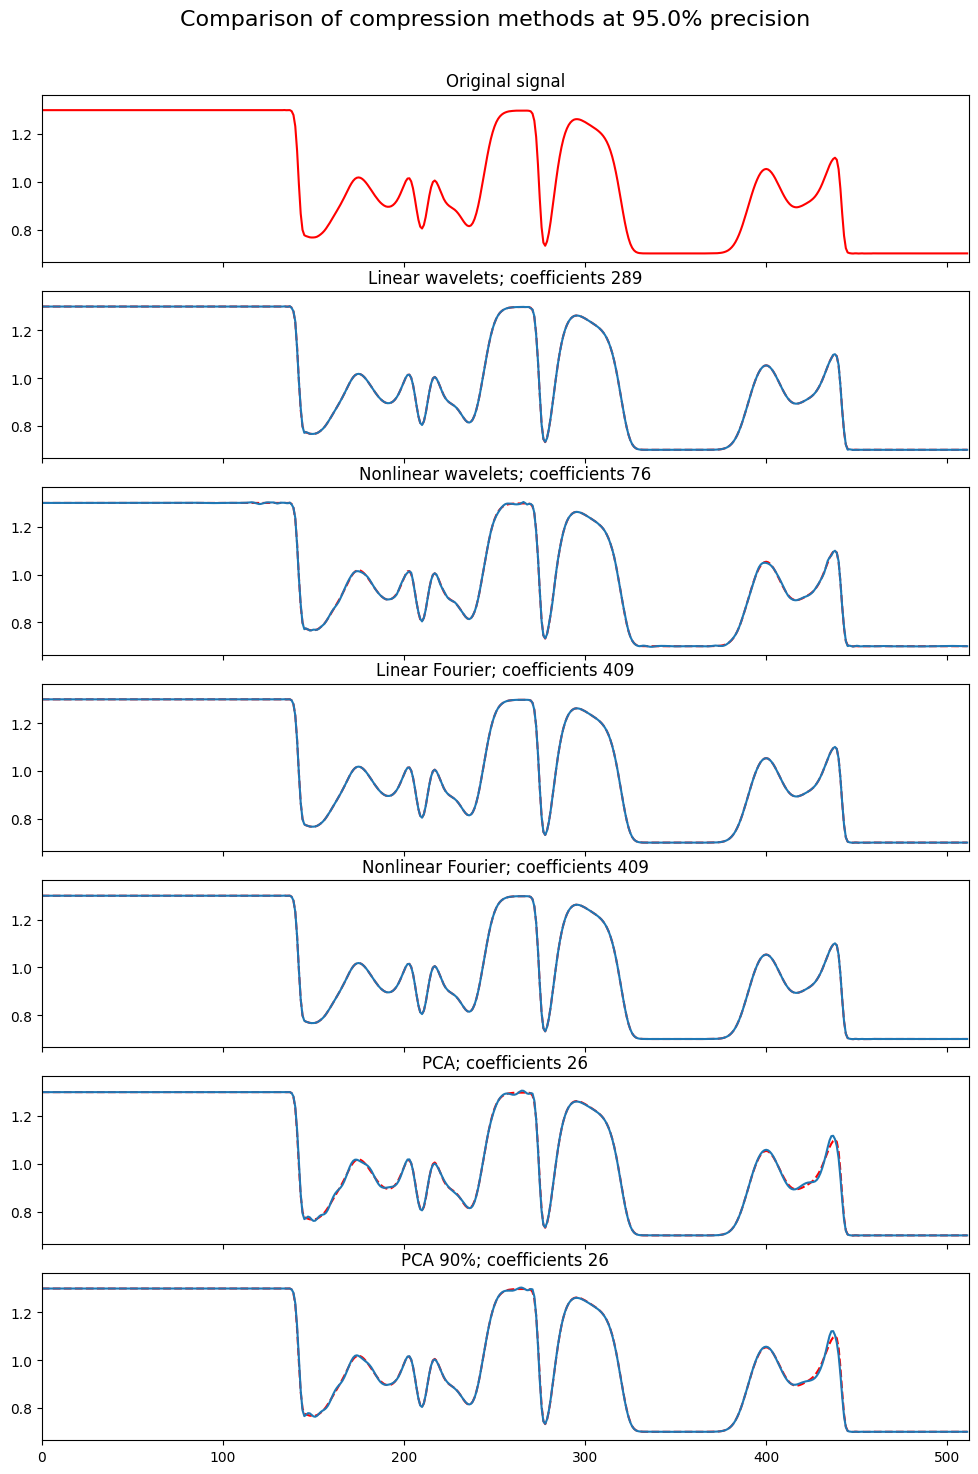

In [22]:
fig, ax = plt.subplots(len(methods)+1, 1, figsize=(10, 15), sharex=True)
y_inf,y_supp = 0.95*np.min(signals[t]),1.05*np.max(signals[t])

fig.suptitle("Comparison of compression methods at "+str((1-T)*100)+"% precision", fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.96])
ax[0].plot(signals[t], color="red")
ax[0].set_xlim(0, signals[t].shape[0])
ax[0].set_title(f'Original signal')
ax[0].set_ylim(y_inf,y_supp)

for i in range(len(methods)):
    ti = str(methods[i]) + "; coefficients " + str(n[i])
    ax[i+1].plot(signals[t], color="red", linestyle="--")
    ax[i+1].plot(si[i,:])
    ax[i+1].set_ylim(y_inf,y_supp)
    ax[i+1].set_title(ti)

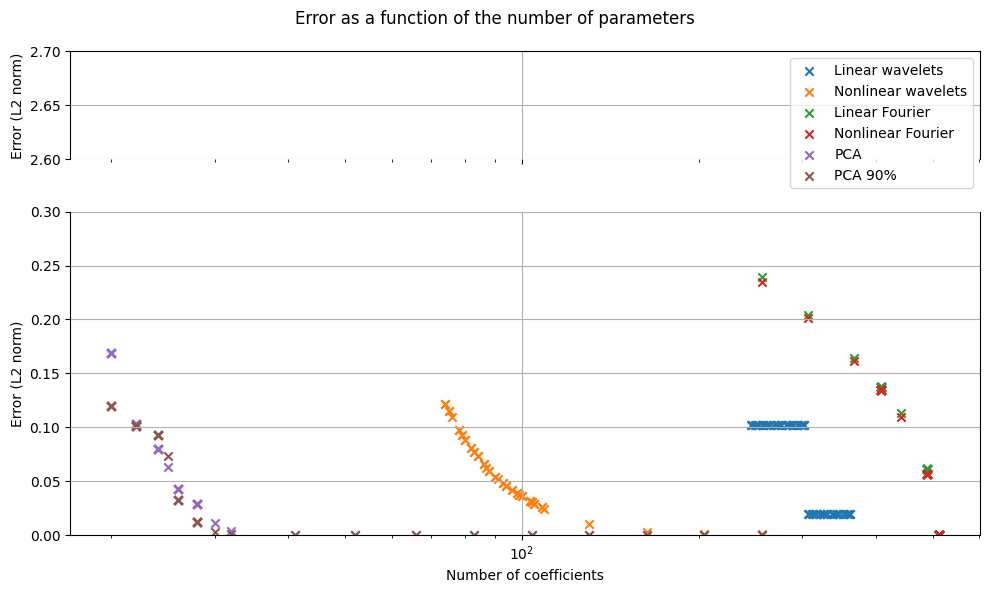

In [23]:
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    sharex=True,
    figsize=(10, 6),
    gridspec_kw={'height_ratios': [1, 3]}
)

for j in range(len(methods)):
    # ax1.plot(errors[j, :, 0], errors[j, :, 1], label=methods[j])
    # ax2.plot(errors[j, :, 0], errors[j, :, 1], label=methods[j])
    ax1.scatter(errors[j, :, 0], errors[j, :, 1],marker='x', label=methods[j])
    ax2.scatter(errors[j, :, 0], errors[j, :, 1],marker='x', label=methods[j])

# ------ Axis limits used to create a break ------ #
ax1.set_ylim(2.6, 2.7)   # upper range
ax2.set_ylim(0, 0.3)     # lower range

ax1.set_xscale('log')
ax2.set_xscale('log')

# ------ Style ------- # 
ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)

ax1.tick_params(labeltop=False)
ax2.xaxis.tick_bottom()

# ------ Labels ------ #
ax2.set_xlabel("Number of coefficients")
ax1.set_ylabel("Error (L2 norm)")
ax2.set_ylabel("Error (L2 norm)")

ax1.legend()
ax1.grid()
ax2.grid()

plt.suptitle("Error as a function of the number of parameters")
plt.tight_layout()
plt.show()

---
## FIXED SAMPLING: error vs number of coefficients

In [24]:
n_fixed = 44 

In [25]:
N = signals.shape[1]
coeff_values = np.unique(np.round(np.geomspace(1, N // 2, num=40)).astype(int))

errors_fixed = np.zeros((len(methods), len(coeff_values)))
si_fixed = np.zeros((len(methods), N))

for ci, n_coeff in enumerate(coeff_values):
    si_fixed[0, :] = wavelet_lineaire(signals[t], n_coeff, wavelet)
    si_fixed[1, :] = wavelet_non_lineaire(signals[t], n_coeff, wavelet)
    si_fixed[2, :] = fourier_lineaire(signals[t], n_coeff)
    si_fixed[3, :] = fourier_non_lineaire(signals[t], n_coeff)
    si_fixed[4, :] = acp_non_lineaire(base_acp, signals[t], n_coeff)
    si_fixed[5, :] = acp_non_lineaire(sbase_acp, signals[t], n_coeff)

    for j in range(len(methods)):
        errors_fixed[j, ci] = np.linalg.norm(si_fixed[j] - signals[t])

In [26]:
for j in range(len(methods)):
    n_idx = np.argmin(np.abs(coeff_values - n_fixed))
    si_fixed[j, :] = [
        wavelet_lineaire,
        wavelet_non_lineaire,
        fourier_lineaire,
        fourier_non_lineaire,
        lambda s, n, *_: acp_non_lineaire(base_acp, s, n),
        lambda s, n, *_: acp_non_lineaire(sbase_acp, s, n),
    ][j](signals[t], coeff_values[n_idx], wavelet) if j < 2 else [
        fourier_lineaire,
        fourier_non_lineaire,
        lambda s, n: acp_non_lineaire(base_acp, s, n),
        lambda s, n: acp_non_lineaire(sbase_acp, s, n),
    ][j - 2](signals[t], coeff_values[n_idx])

In [27]:
N = signals.shape[1]
coeff_values = np.unique(np.round(np.geomspace(1, N // 2, num=40)).astype(int))
errors_fixed = np.zeros((len(methods), len(coeff_values)))

def reconstruct(j, sig, n_coeff):
    """Apply method j with n_coeff coefficients."""
    if j == 0: return wavelet_lineaire(sig, n_coeff, wavelet)
    if j == 1: return wavelet_non_lineaire(sig, n_coeff, wavelet)
    if j == 2: return fourier_lineaire(sig, n_coeff)
    if j == 3: return fourier_non_lineaire(sig, n_coeff)
    if j == 4: return acp_non_lineaire(base_acp, sig, n_coeff)
    if j == 5: return acp_non_lineaire(sbase_acp, sig, n_coeff)

for ci, n_coeff in enumerate(coeff_values):
    for j in range(len(methods)):
        sig_rec = reconstruct(j, signals[t], n_coeff)
        errors_fixed[j, ci] = np.linalg.norm(sig_rec - signals[t])

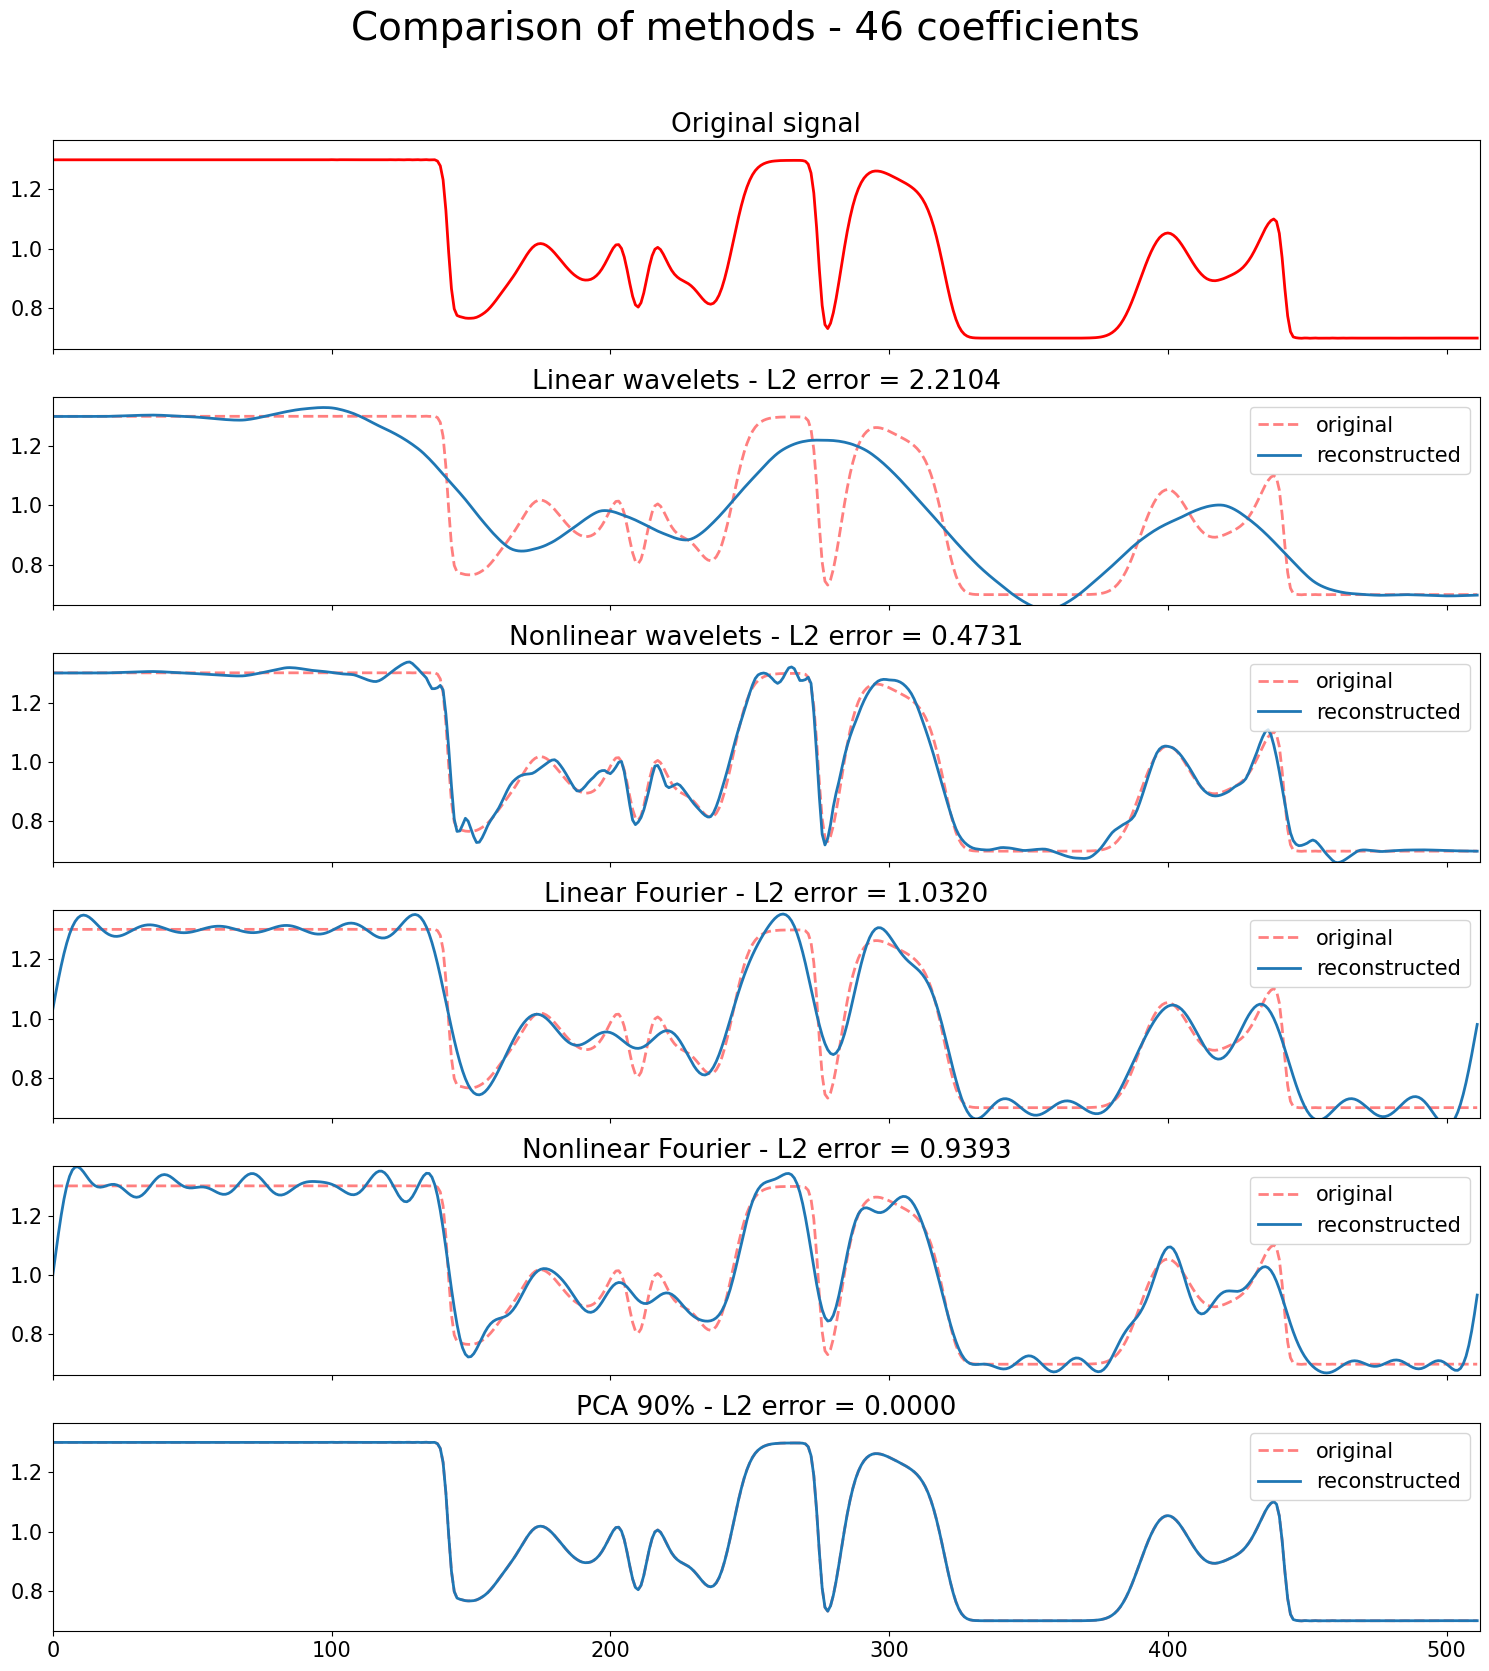

In [28]:
methods = [
    "Linear wavelets",
    "Nonlinear wavelets",
    "Linear Fourier",
    "Nonlinear Fourier",
    # "PCA",
    "PCA " + str(pACP) + "%"
]

n_idx   = np.argmin(np.abs(coeff_values - n_fixed))
n_actual = coeff_values[n_idx]

y_inf  = 0.95 * np.min(signals[t])
y_supp = 1.05 * np.max(signals[t])

title_fontsize = 28
subplot_title_fontsize = 19
tick_fontsize = 15
legend_fontsize = 15
line_width = 2.0

fig, ax = plt.subplots(len(methods) + 1, 1, figsize=(15, 17), sharex=True)
fig.suptitle(f"Comparison of methods - {n_actual} coefficients", fontsize=title_fontsize)

ax[0].plot(signals[t], color="red", linewidth=line_width)
ax[0].set_title("Original signal", fontsize=subplot_title_fontsize)
ax[0].set_ylim(y_inf, y_supp)
ax[0].set_xlim(0, N)

for j in range(len(methods)):
    sig_rec = reconstruct(j, signals[t], n_actual)
    err     = np.linalg.norm(sig_rec - signals[t])
    ax[j+1].plot(signals[t], color="red", linestyle="--", alpha=0.5, linewidth=line_width, label="original")
    ax[j+1].plot(sig_rec, linewidth=line_width, label="reconstructed")
    ax[j+1].set_ylim(y_inf, y_supp)
    ax[j+1].set_title(f"{methods[j]} - L2 error = {err:.4f}", fontsize=subplot_title_fontsize)
    ax[j+1].legend(loc="upper right", fontsize=legend_fontsize)

for axi in ax:
    axi.tick_params(axis="both", labelsize=tick_fontsize)

fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("../outputs/img/1D_Comparaison.png", dpi=300)
plt.show()

/tmp/ipykernel_2038098/2564061016.py:19: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax2.set_xlim(x_min, x_max)


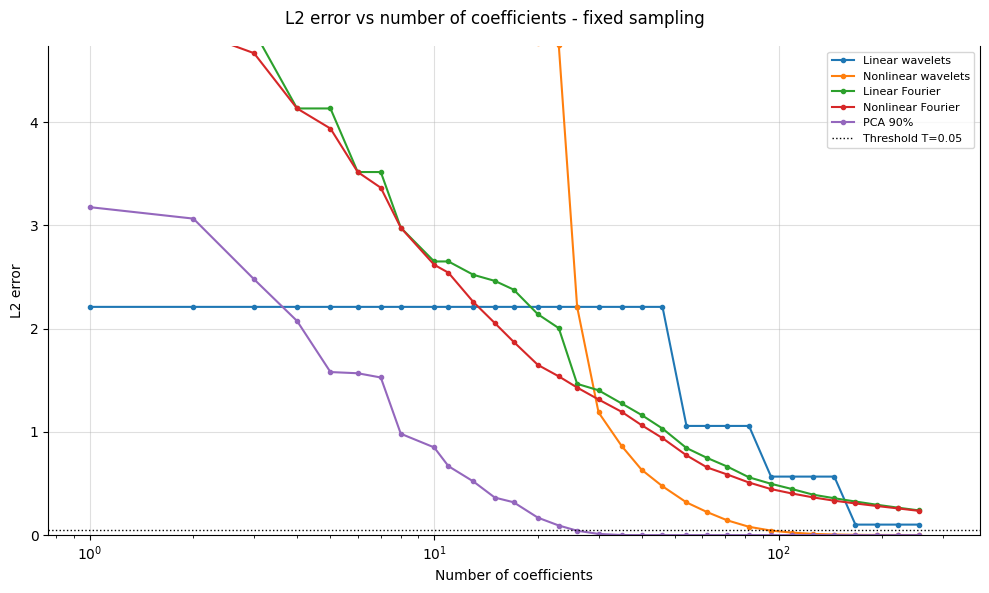

In [29]:
fig, ax2 = plt.subplots(
    1, 1, sharex=True, figsize=(10, 6),
)

for j in range(len(methods)):
    ax2.plot(coeff_values, errors_fixed[j], marker='o', markersize=3, label=methods[j])

ax2.axhline(y=T, color='black', linestyle=':', linewidth=1, label=f"Threshold T={T}")

ax2.set_ylim(0, np.percentile(errors_fixed, 90))

ax2.spines['top'].set_visible(False)
ax2.xaxis.tick_bottom()

ax2.set_xscale('log')  

x_min = 0
x_max = coeff_values[-1] * 1.5 
ax2.set_xlim(x_min, x_max)      
ax2.legend(fontsize=8, loc="upper right")
ax2.set_xlabel("Number of coefficients")
ax2.set_ylabel("L2 error")
ax2.grid(True, alpha=0.4)

plt.suptitle("L2 error vs number of coefficients - fixed sampling")
plt.tight_layout()
plt.show()

/tmp/ipykernel_2038098/1424292405.py:27: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax1.set_xlim(x_min, x_max)
/tmp/ipykernel_2038098/1424292405.py:28: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax2.set_xlim(x_min, x_max)


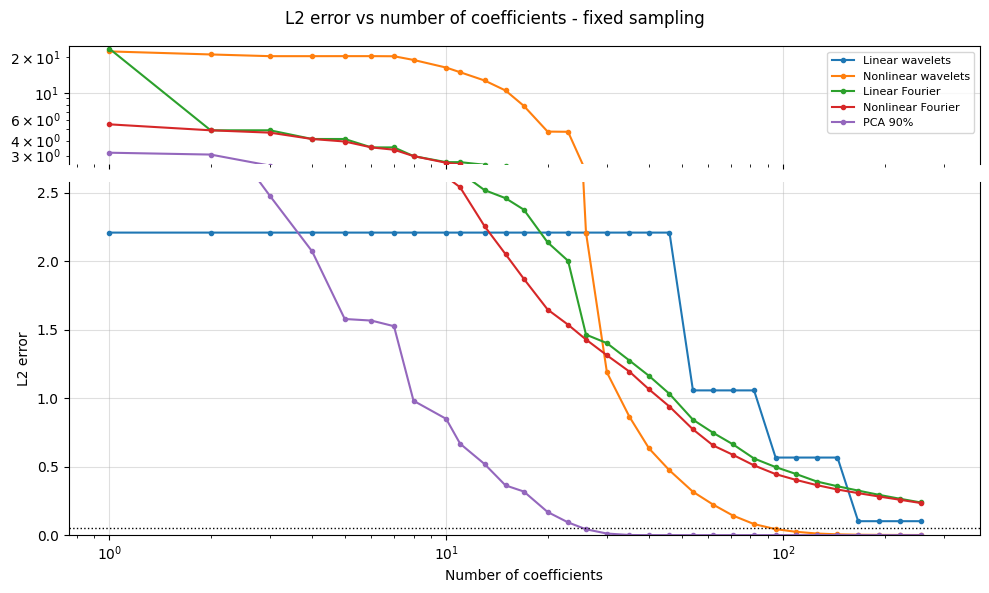

In [30]:
fig, (ax1, ax2) = plt.subplots(
    2, 1, sharex=True, figsize=(10, 6),
    gridspec_kw={'height_ratios': [1, 3]}
)

for j in range(len(methods)):
    ax1.plot(coeff_values, errors_fixed[j], marker='o', markersize=3, label=methods[j])
    ax2.plot(coeff_values, errors_fixed[j], marker='o', markersize=3, label=methods[j])

# Threshold T for reference
ax2.axhline(y=T, color='black', linestyle=':', linewidth=1, label=f"Threshold T={T}")

# Broken axis
ax1.set_ylim(np.percentile(errors_fixed, 80), errors_fixed.max() * 1.05)
ax2.set_ylim(0, np.percentile(errors_fixed, 80))

ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax1.tick_params(labelbottom=False)
ax2.xaxis.tick_bottom()

# --- Fix: log scale + identical and explicit xlim on both axes ---
ax2.set_xscale('log')  # enough because of sharex, but xlim is set manually
ax1.set_yscale('log')
x_min = 0  
x_max = coeff_values[-1] * 1.5  
ax1.set_xlim(x_min, x_max)
ax2.set_xlim(x_min, x_max)

ax2.set_xlabel("Number of coefficients")
ax2.set_ylabel("L2 error")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.4)
ax2.grid(True, alpha=0.4)

plt.suptitle("L2 error vs number of coefficients - fixed sampling")
plt.tight_layout()
plt.show()